## Question 1

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


In [6]:
def intensity_transform(im, breakpoints):
    """
    Applying a piecewise-linear intensity transformation defined by breakpoints.
    """
    bp = np.array(breakpoints, dtype=np.float64)
    lut = np.zeros(256, dtype=np.float64)
    levels = np.arange(256)

    for i in range(len(bp) - 1):
        x0, y0 = bp[i]
        x1, y1 = bp[i + 1]
        if i == len(bp) - 2:
            mask = (levels >= x0) & (levels <= x1)
        else:
            mask = (levels >= x0) & (levels < x1)
        if x1 == x0:
            lut[mask] = y1
        else:
            lut[mask] = y0 + (y1 - y0) * (levels[mask] - x0) / (x1 - x0)

    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return cv2.LUT(im, lut), lut


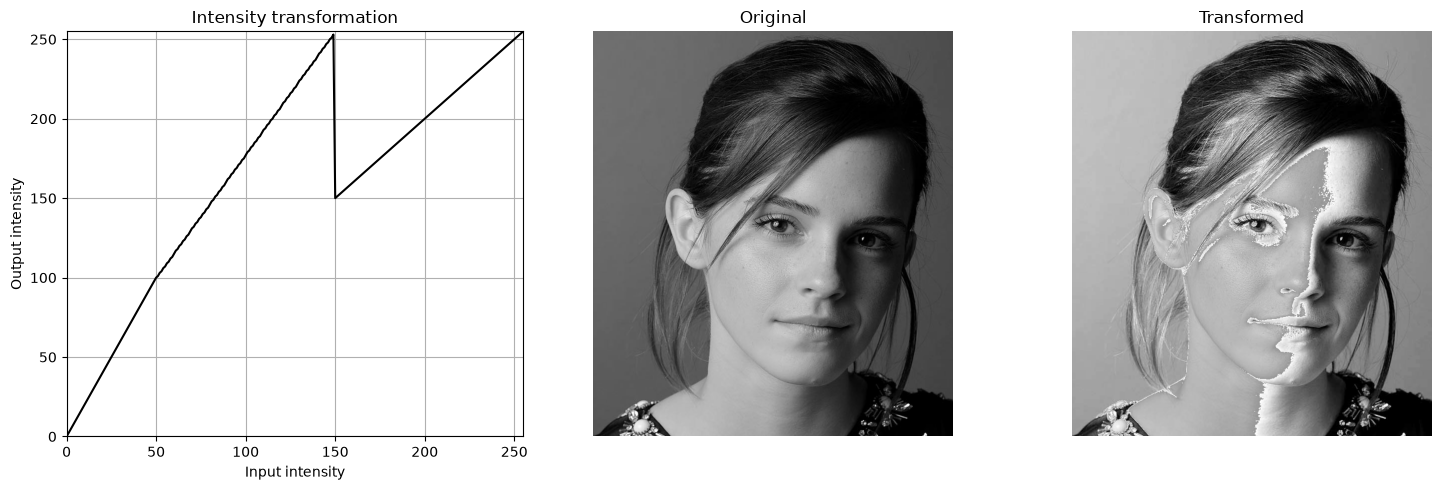

In [7]:
img = cv2.imread('images/emma.jpg', cv2.IMREAD_GRAYSCALE)

breakpoints = [[0, 0], [50, 100], [150, 255], [150, 150], [255, 255]]

transformed, lut = intensity_transform(img, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), lut, color='k')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity transformation')
axes[0].grid(True)

axes[1].imshow(img, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(transformed, cmap='gray')
axes[2].set_title('Transformed')
axes[2].axis('off')

plt.tight_layout()
plt.show()
